# Dataset Visualization Notebook

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from omegaconf import OmegaConf
import random
import torch

import pandas as pd
import albumentations as A

# repo root
REPO_ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(REPO_ROOT))

# dataset classes
from src.dataset import (
    NormalizationLayer,
    TileImg2ImgSlideDataset,
    Img2ImgNucleiSlideDataset,
    get_width_height,
    get_effective_width_height,
)
from benchmark.data.dataset import LizardDataset, TileDataset 

/opt/local/anaconda3/envs/miphei/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/local/anaconda3/envs/miphei/lib/python3.11/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def visualize_sample(sample, title=""):
    img = sample["image"]
    if torch.is_tensor(img):
        img = img.permute(1,2,0).cpu().numpy()

    ncols = 1
    if "target" in sample: ncols += 1
    if "nuclei" in sample: ncols += 1

    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
    if ncols == 1:
        axes = [axes]
    i = 0

    axes[i].imshow(img)
    axes[i].set_title(f"{title} — H&E")
    axes[i].axis("off")
    i += 1

    if "target" in sample:
        targ = sample["target"]
        if torch.is_tensor(targ):
            targ = targ.permute(1,2,0).cpu().numpy()

        # visualization: pick 3 channels
        if targ.shape[-1] >= 3:
            vis = targ[..., [0, targ.shape[-1]//2, targ.shape[-1]-1]]
            vis = vis / (np.percentile(vis, 99.9) + 1e-6)
            vis = np.clip(vis, 0, 1)
            axes[i].imshow(vis)
        else:
            axes[i].imshow(np.mean(targ, axis=-1), cmap="magma")

        axes[i].set_title("Target IF")
        axes[i].axis("off")
        i += 1

    if "nuclei" in sample:
        nuc = sample["nuclei"]
        if torch.is_tensor(nuc):
            nuc = nuc.cpu().numpy()
        rgb = label2rgb(nuc, bg_label=0, bg_color=(0,0,0))
        axes[i].imshow(rgb)
        axes[i].set_title("Nuclei")
        axes[i].axis("off")

    plt.show()

## OrionCRC Dataset

In [3]:
# --- CONFIG PATHS ---
cfg_path = "../configs/data/orion.yaml"
cfg = pd.read_csv  # just keeping syntax highlighting correct

cfg = OmegaConf.load(cfg_path)

df = pd.read_csv(cfg.data.test_dataframe_path)

# compute effective crop
width, height = get_width_height(df)
width_crop, height_crop = get_effective_width_height(width, height, train=True)

# Albumentations crop
spatial_aug = A.Compose([
    A.CenterCrop(width=width_crop, height=height_crop),
], additional_targets={"image_target": "image", "nuclei": "image"})

orion_dataset = TileImg2ImgSlideDataset(
    dataframe=df,
    preprocess_input_fn=None,
    preprocess_target_fn=None,
    targ_channel_idxs=list(range(len(cfg.data.targ_channel_names))),
    spatial_augmentations=spatial_aug,
    return_nuclei=True,
)

print("Dataset size:", len(orion_dataset))

Dataset size: 10952


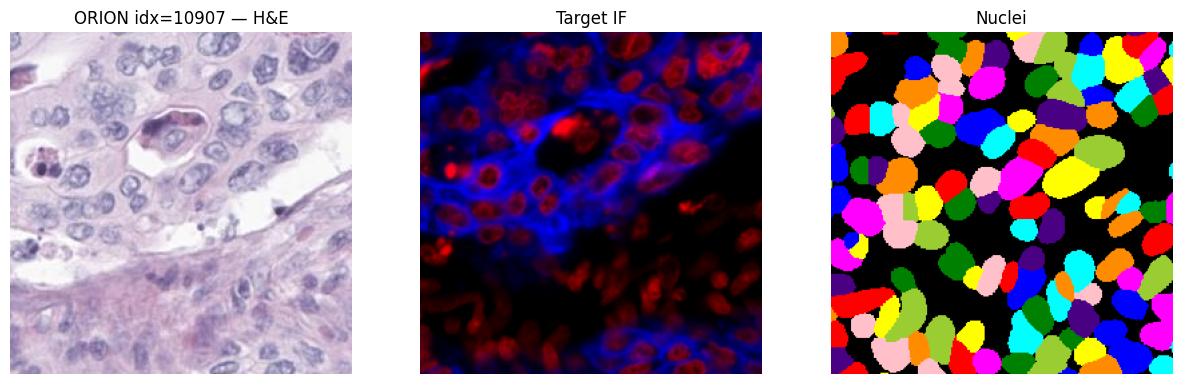

In [4]:
idx = random.randint(0, len(orion_dataset)-1)
sample = orion_dataset[idx]
visualize_sample(sample, title=f"ORION idx={idx}")

## HEMIT Dataset

In [5]:
cfg_path = "../configs/data/hemit.yaml"
cfg = OmegaConf.load(cfg_path)

df = pd.concat([
    pd.read_csv(cfg.data.train_dataframe_path),
    pd.read_csv(cfg.data.val_dataframe_path),
    pd.read_csv(cfg.data.test_dataframe_path),
])

width, height = 1024, 1024
width_crop, height_crop = width//2, height//2

spatial_aug = A.Compose([
    A.Resize(width=width_crop, height=height_crop),
    A.CenterCrop(width=width_crop, height=height_crop),
], additional_targets={"image_target": "image", "nuclei": "mask"})

hemit_dataset = TileImg2ImgSlideDataset(
    dataframe=df,
    preprocess_input_fn=None,
    preprocess_target_fn=None,
    targ_channel_idxs=list(range(len(cfg.data.targ_channel_names))),
    spatial_augmentations=spatial_aug,
    return_nuclei=True,
)

len(hemit_dataset)

5292

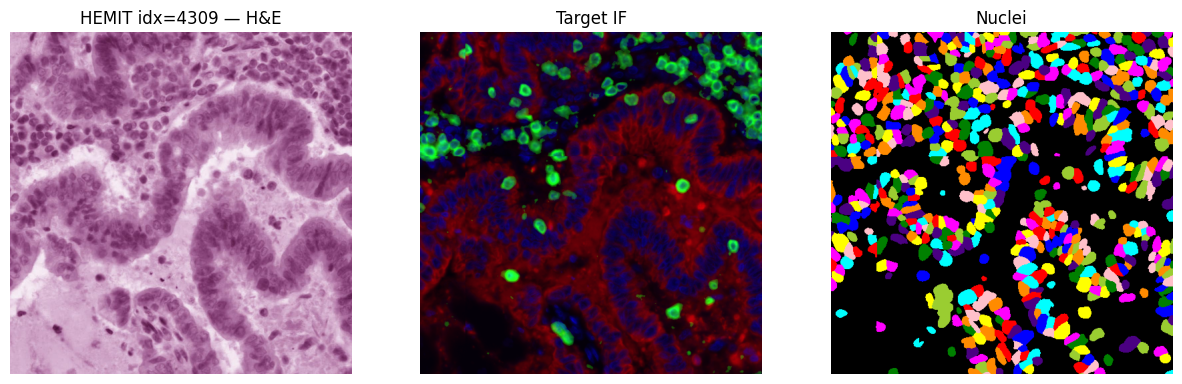

In [6]:
idx = random.randint(0, len(hemit_dataset)-1)
visualize_sample(hemit_dataset[idx], title=f"HEMIT idx={idx}")

## PathoCell Dataset

In [7]:
cfg_path = "../configs/data/pathocell.yaml"
cfg = OmegaConf.load(cfg_path)

df = pd.read_csv(cfg.data.test_dataframe_path)
slide_df = pd.read_csv(cfg.data.slide_dataframe_path)

width, height = get_width_height(df)
width_crop, height_crop = get_effective_width_height(width, height, train=True)

spatial_aug = A.Compose([
    A.CenterCrop(width=width_crop, height=height_crop),
], additional_targets={"image_target": "image", "nuclei": "image"})

pathocell_dataset = Img2ImgNucleiSlideDataset(
    slide_dataframe=slide_df,
    dataframe=df,
    preprocess_input_fn=None,
    preprocess_target_fn=None,
    targ_channel_idxs=list(range(len(cfg.data.targ_channel_names))),
    mode_targ="IF",
    spatial_augmentations=spatial_aug,
    return_nuclei=True,
)

len(pathocell_dataset)


4852

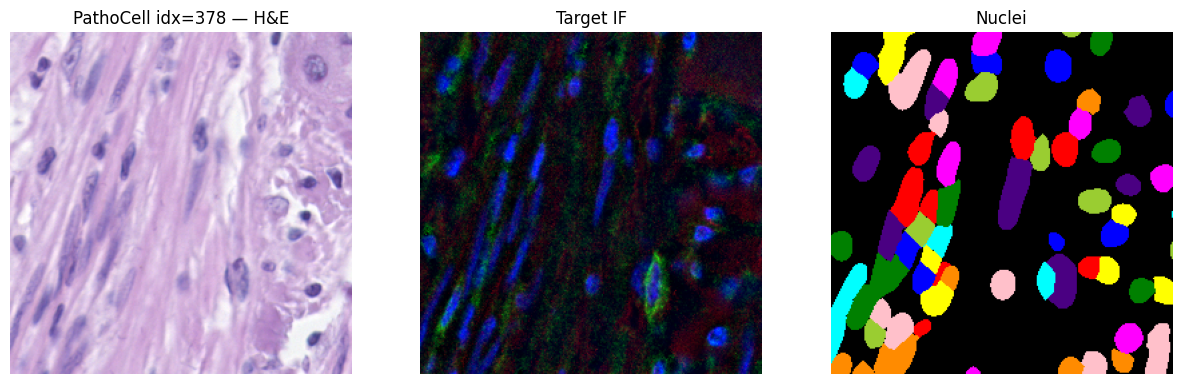

In [10]:
idx = random.randint(0, len(pathocell_dataset)-1)
visualize_sample(pathocell_dataset[idx], title=f"PathoCell idx={idx}")


## Lizard Dataset

In [11]:
cfg_path = "../configs/data/lizard.yaml"
cfg = OmegaConf.load(cfg_path)

df = pd.read_csv(cfg.data.test_dataframe_path)
slide_df = pd.read_csv(cfg.data.slide_dataframe_path)

width, height = get_width_height(df)
width_crop, height_crop = get_effective_width_height(width, height, train=True)

spatial_aug = A.Compose([
    A.CenterCrop(width=width_crop, height=height_crop),
], additional_targets={"image_target": "image", "nuclei": "image"})

lizard_dataset = LizardDataset(
    slide_dataframe=slide_df,
    dataframe=df,
    mpp=0.5,
    preprocess_input_fn=None,
    spatial_augmentations=spatial_aug,
    return_nuclei=True,
)

len(lizard_dataset)


4777

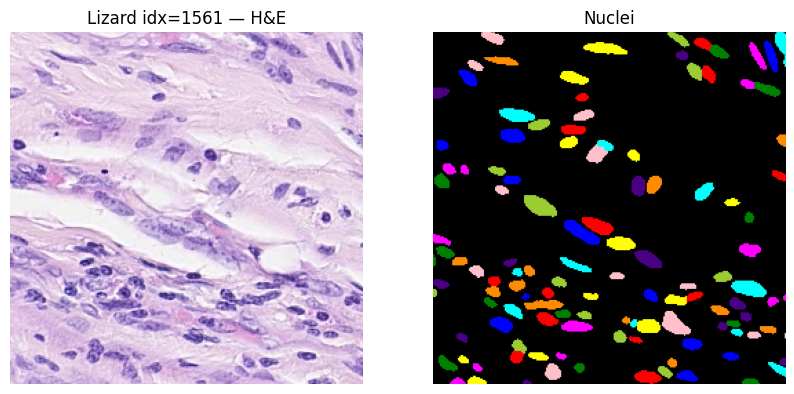

In [12]:
idx = random.randint(0, len(lizard_dataset)-1)
visualize_sample(lizard_dataset[idx], title=f"Lizard idx={idx}")


## PanNuke Dataset

In [13]:
cfg_path = "../configs/data/pannuke.yaml"
cfg = OmegaConf.load(cfg_path)

df = pd.read_csv(cfg.data.test_dataframe_path)

width, height = get_width_height(df)
width_crop, height_crop = get_effective_width_height(width, height, train=True)

spatial_aug = A.Compose([
    A.CenterCrop(width=width_crop, height=height_crop),
], additional_targets={"image_target": "image", "nuclei": "image"})

pannuke_dataset = TileDataset(
    dataframe=df,
    preprocess_input_fn=None,
    spatial_augmentations=spatial_aug,
    return_nuclei=True,
)

len(pannuke_dataset)


7901

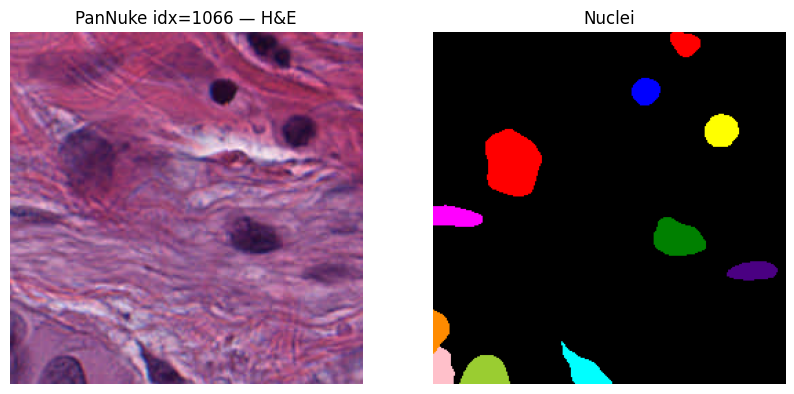

In [15]:
idx = random.randint(0, len(pannuke_dataset)-1)
visualize_sample(pannuke_dataset[idx], title=f"PanNuke idx={idx}")
